# Price Tagging - CPI Analysis and Forecasting

This notebook analyzes and forecasts the Consumer Price Index (CPI) for selected countries, following the APST project requirements.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import itertools
from statsmodels.tsa.seasonal import STL
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.holtwinters import ExponentialSmoothing
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from scipy.stats import norm
from sklearn.metrics import mean_squared_error, mean_absolute_error, mean_absolute_percentage_error

%matplotlib inline
sns.set_theme(style="whitegrid")

## 1. Data Loading and Filtering
We load the CPI time series and focus on the `PCPI_IX` indicator (Consumer Price Index, All items) from 1990 onwards.

In [2]:
# Load dataset
df = pd.read_csv("data/CPITimeSeries.csv", low_memory=False)

# Filter for the required indicator and 'Value' attribute
df_pcpi = df[(df["Indicator Code"] == "PCPI_IX") & (df["Attribute"] == "Value")].copy()

# Identify date columns from 1990 onwards
date_cols = [c for c in df.columns if 'M' in c and c[:4].isdigit() and int(c[:4]) >= 1990]

# Keep only relevant columns
df_filtered = df_pcpi[["Country Name"] + date_cols].set_index("Country Name")

# Convert data to numeric, handling potential errors
df_filtered = df_filtered.apply(pd.to_numeric, errors='coerce')

print(f"Total months from 1990: {len(date_cols)}")

Total months from 1990: 392


## 2. Verifying Data Coverage
We check the coverage for our selected countries: **Poland** and **Slovenia**.

In [3]:
def check_coverage(countries):
    for c in countries:
        if c in df_filtered.index:
            non_null = df_filtered.loc[c].notna().sum()
            coverage = (non_null / len(date_cols)) * 100
            print(f"{c}: {non_null} months ({coverage:.1f}% coverage)")
        else:
            print(f"{c} not found in dataset")

target_countries = ["Poland, Rep. of", "Slovenia, Rep. of"]
check_coverage(target_countries)

Poland, Rep. of: 392 months (100.0% coverage)
Slovenia, Rep. of: 392 months (100.0% coverage)


## 3. Data Visualization
Extracting and plotting the time series for Poland and Slovenia.

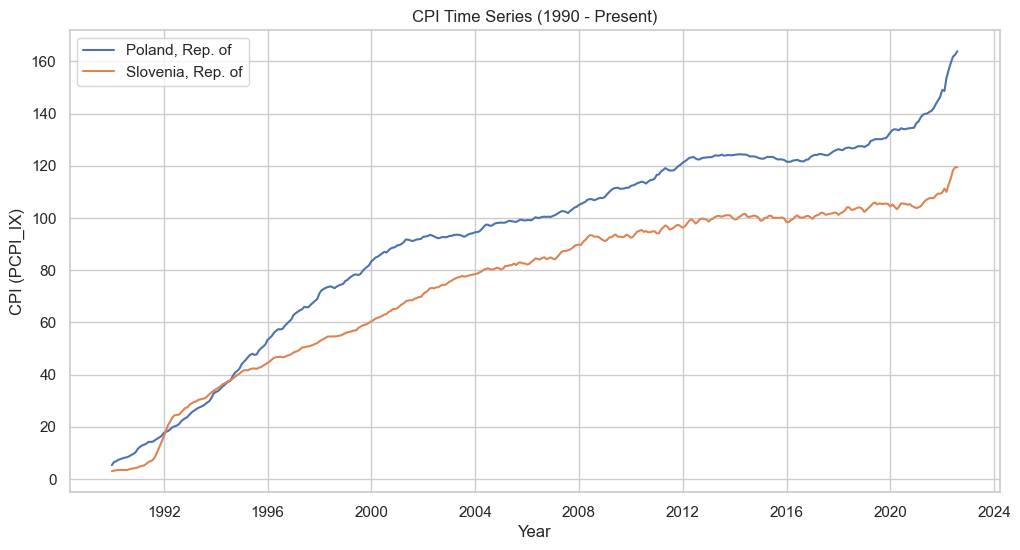

In [4]:
primary_country = "Poland, Rep. of"
secondary_country = "Slovenia, Rep. of"

# Extract time series
ts_primary = df_filtered.loc[primary_country].dropna()
ts_secondary = df_filtered.loc[secondary_country].dropna()

# Convert index to datetime
def convert_to_datetime(idx):
    return pd.to_datetime([c.replace('M', '-') for c in idx])

ts_primary.index = convert_to_datetime(ts_primary.index)
ts_secondary.index = convert_to_datetime(ts_secondary.index)

plt.figure(figsize=(12, 6))
plt.plot(ts_primary, label=primary_country)
plt.plot(ts_secondary, label=secondary_country)
plt.title("CPI Time Series (1990 - Present)")
plt.xlabel("Year")
plt.ylabel("CPI (PCPI_IX)")
plt.legend()
plt.show()

## 4. Time Series Analysis

### 4.1 Time Series Splitting
We split the Poland CPI time series into Training, Validation, and Test sets using chronological splitting. 

**Splitting Logic:**
- **Train:** Jan 1990 to Dec 2016
- **Validation:** Jan 2017 to Dec 2020 (4 full years)
- **Test:** Jan 2021 to Aug 2022

This follows standard chronological splitting practices as documented in the [Pandas User Guide on Indexing](https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#datetime-indexing).

Train set: 1990-01 to 2016-12 (324 months)
Validation set: 2017-01 to 2020-12 (48 months)
Test set: 2021-01 to 2022-08 (20 months)


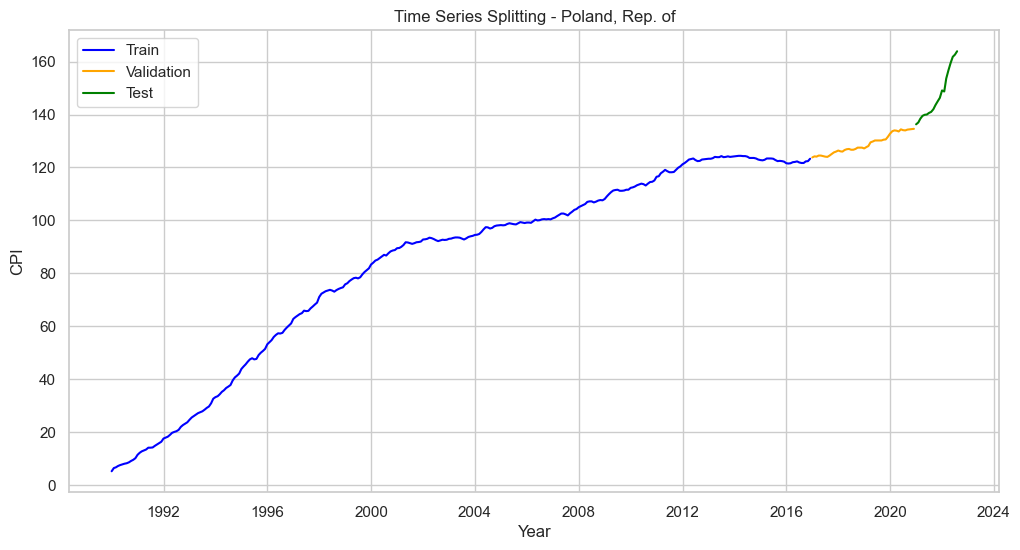

In [5]:
# Split the data for Poland
train = ts_primary['1990-01':'2016-12']
val = ts_primary['2017-01':'2020-12']
test = ts_primary['2021-01':]

print(f"Train set: {train.index.min().strftime('%Y-%m')} to {train.index.max().strftime('%Y-%m')} ({len(train)} months)")
print(f"Validation set: {val.index.min().strftime('%Y-%m')} to {val.index.max().strftime('%Y-%m')} ({len(val)} months)")
print(f"Test set: {test.index.min().strftime('%Y-%m')} to {test.index.max().strftime('%Y-%m')} ({len(test)} months)")

# Visualize the split
plt.figure(figsize=(12, 6))
plt.plot(train, label='Train', color='blue')
plt.plot(val, label='Validation', color='orange')
plt.plot(test, label='Test', color='green')
plt.title(f"Time Series Splitting - {primary_country}")
plt.xlabel("Year")
plt.ylabel("CPI")
plt.legend()
plt.show()

### 4.2 Basic Description Techniques & Transformations

#### Seasonal and Trend decomposition using Loess (STL)
We use the STL method to decompose the series into its trend, seasonal, and residual components. To avoid data leakage, we perform this analysis only on the training set.

Method sourced from [statsmodels STL documentation](https://www.statsmodels.org/stable/generated/statsmodels.tsa.seasonal.STL.html).

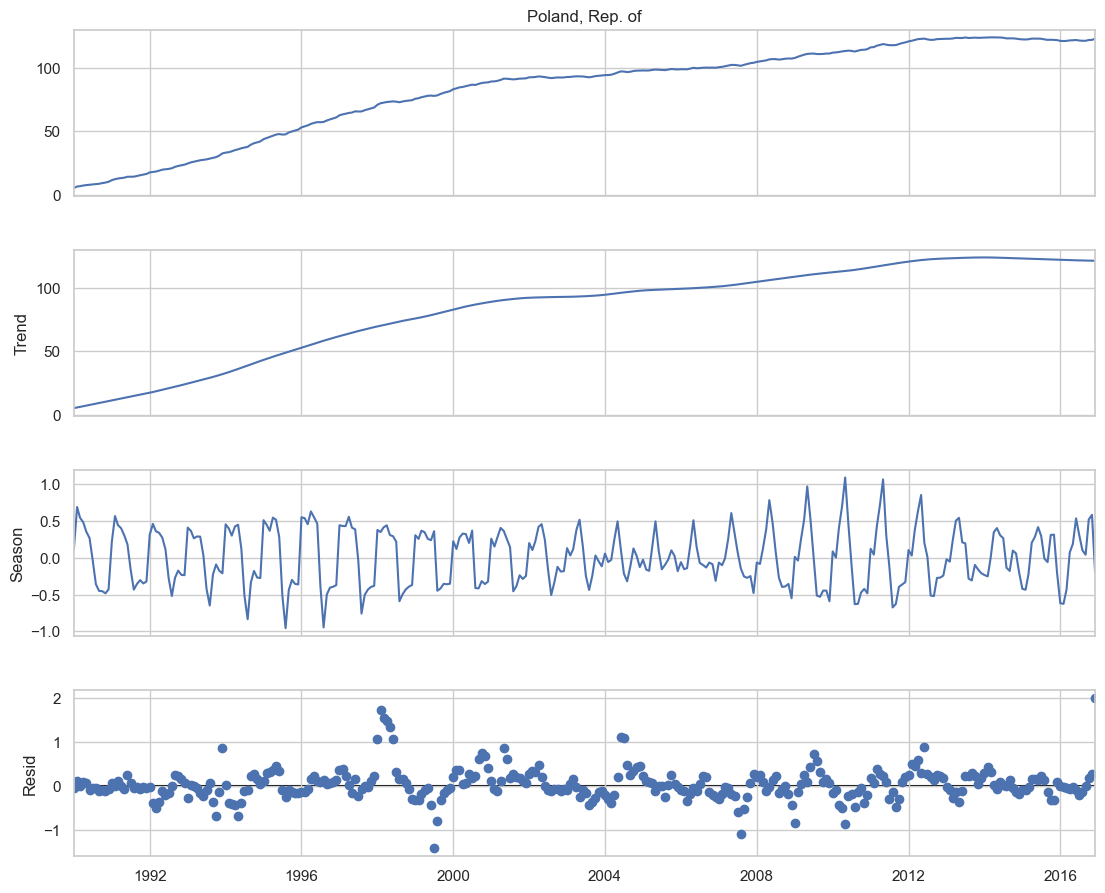

In [6]:
# STL Decomposition on training data
stl = STL(train, period=12, robust=True)
res = stl.fit()

fig = res.plot()
fig.set_size_inches(12, 10)
plt.show()

# Separate components for potential further use
trend = res.trend
seasonal = res.seasonal
residual = res.resid

#### Stationarity Assessment (ADF Test)
We assess the stationarity of the training series using the Augmented Dickey-Fuller (ADF) test. If the series is non-stationary, we apply differencing to stationarize it.

Method sourced from [statsmodels ADF documentation](https://www.statsmodels.org/stable/generated/statsmodels.tsa.stattools.adfuller.html).

--- ADF Test Result for Original Training Series ---
ADF Statistic: -2.6909313774819115
p-value: 0.07562072629347483
Critical Values:
	1%: -3.451621854687657
	5%: -2.870908950689806
	10%: -2.571761810613944
Result: Non-Stationary (Fail to reject H0)
--- ADF Test Result for First-order Differenced Training Series ---
ADF Statistic: -1.5185618944378036
p-value: 0.5243098700830986
Critical Values:
	1%: -3.451621854687657
	5%: -2.870908950689806
	10%: -2.571761810613944
Result: Non-Stationary (Fail to reject H0)
--- ADF Test Result for Second-order Differenced Training Series ---
ADF Statistic: -10.02886898869046
p-value: 1.6047298161489972e-17
Critical Values:
	1%: -3.451621854687657
	5%: -2.870908950689806
	10%: -2.571761810613944
Result: Stationary (Reject H0)


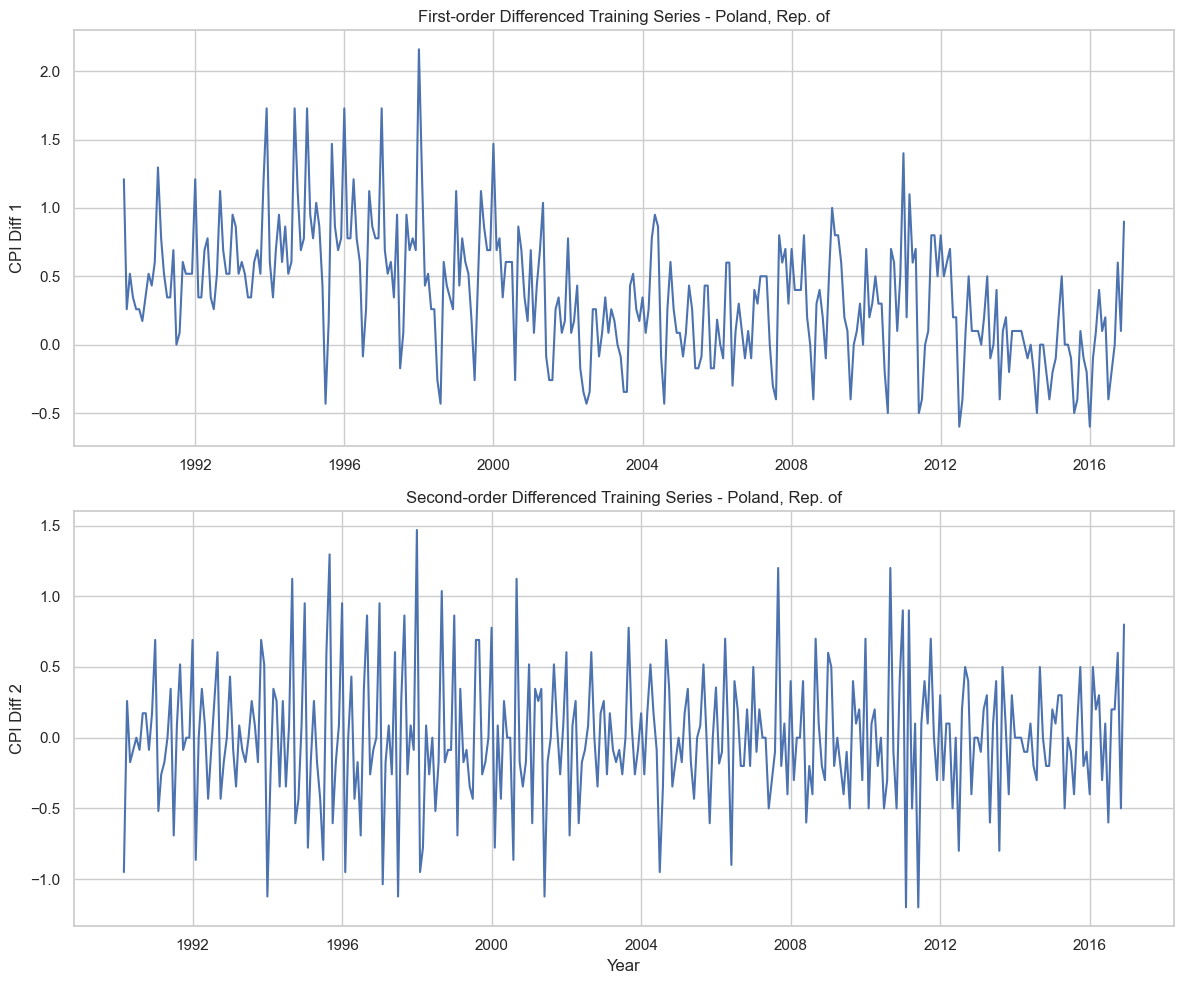

In [7]:
def check_stationarity(timeseries, title="Series"):
    print(f"--- ADF Test Result for {title} ---")
    result = adfuller(timeseries)
    print(f'ADF Statistic: {result[0]}')
    print(f'p-value: {result[1]}')
    print('Critical Values:')
    for key, value in result[4].items():
        print(f'\t{key}: {value}')
    
    if result[1] <= 0.05:
        print("Result: Stationary (Reject H0)")
    else:
        print("Result: Non-Stationary (Fail to reject H0)")

# Check stationarity of original train series
check_stationarity(train, "Original Training Series")

# First-order differencing
train_diff1 = train.diff().dropna()
check_stationarity(train_diff1, "First-order Differenced Training Series")

# Second-order differencing (requested if first-order is non-stationary)
train_diff2 = train_diff1.diff().dropna()
check_stationarity(train_diff2, "Second-order Differenced Training Series")

# Plot both differenced series for comparison
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 10))

ax1.plot(train_diff1)
ax1.set_title(f"First-order Differenced Training Series - {primary_country}")
ax1.set_ylabel("CPI Diff 1")

ax2.plot(train_diff2)
ax2.set_title(f"Second-order Differenced Training Series - {primary_country}")
ax2.set_xlabel("Year")
ax2.set_ylabel("CPI Diff 2")

plt.tight_layout()
plt.show()

### 4.3 Statistical Modeling (SARIMA)

#### 4.3.1 Parameter Discovery via ACF/PACF
We analyze the Auto-Correlation Function (ACF) and Partial Auto-Correlation Function (PACF) of the second-order differenced series to identify potential AR and MA components (both regular and seasonal).

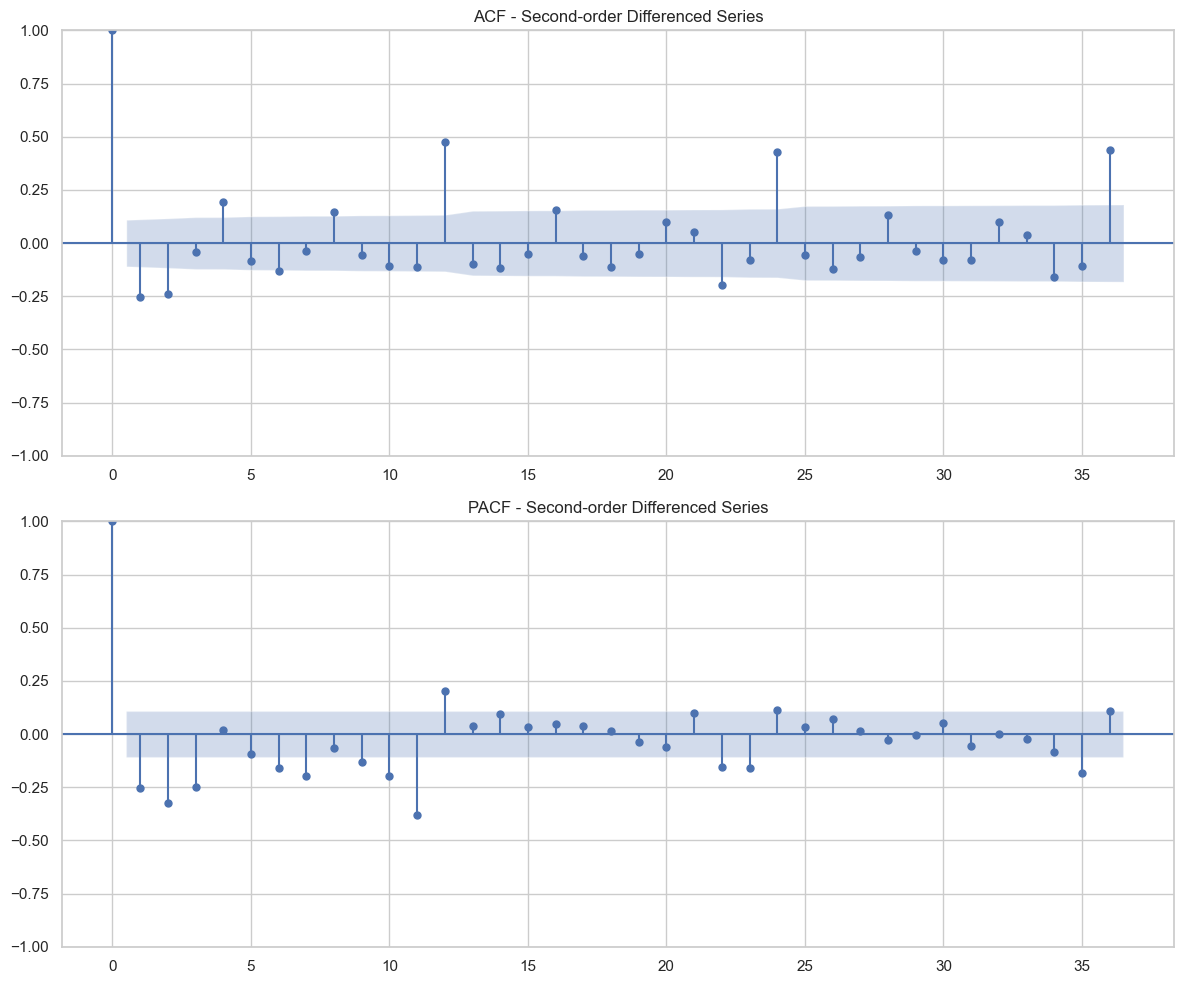

In [8]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 10))

plot_acf(train_diff2, lags=36, ax=ax1, title="ACF - Second-order Differenced Series")
plot_pacf(train_diff2, lags=36, ax=ax2, title="PACF - Second-order Differenced Series")

plt.tight_layout()
plt.show()

#### ACF Theoretical Distribution Check
We compare the empirical distribution of the ACF values against a theoretical Normal distribution $\mathcal{N}(0, 1/\sqrt{N})$ to check if the residuals of the differenced series behave like white noise.

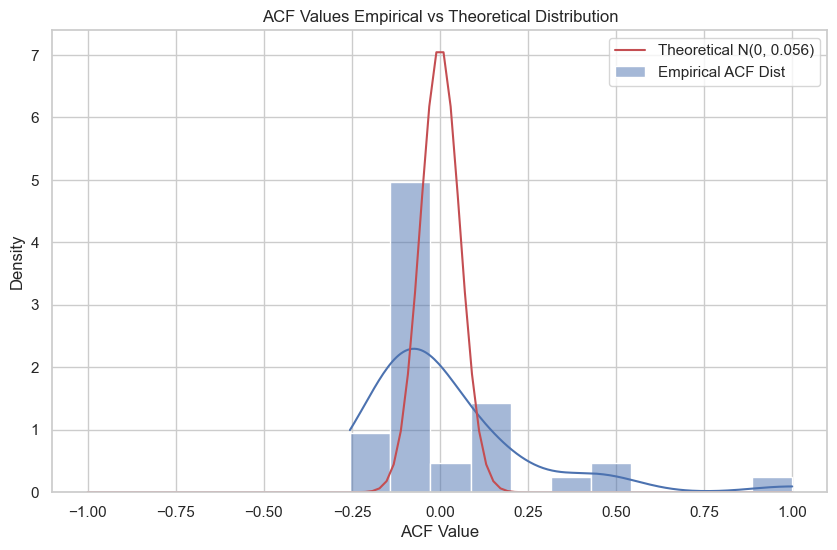

In [9]:
from statsmodels.tsa.stattools import acf

acf_values = acf(train_diff2, nlags=36)
N = len(train_diff2)
std_dev = 1 / np.sqrt(N)

plt.figure(figsize=(10, 6))
sns.histplot(acf_values, kde=True, stat="density", label="Empirical ACF Dist")
x = np.linspace(-1, 1, 100)
plt.plot(x, norm.pdf(x, 0, std_dev), 'r', label=f"Theoretical N(0, {std_dev:.3f})")
plt.title("ACF Values Empirical vs Theoretical Distribution")
plt.xlabel("ACF Value")
plt.ylabel("Density")
plt.legend()
plt.show()

#### 4.3.2 SARIMA Grid Search
We perform a grid search to find the optimal SARIMA $(p, 2, q) \times (P, D, Q)_{12}$ parameters based on AIC and BIC scores.

In [10]:
import warnings
warnings.filterwarnings("ignore")

p = q = range(0, 3)
d = [2]
P = Q = range(0, 2)
D = [0, 1]
s = [12]

pdq = list(itertools.product(p, d, q))
seasonal_pdq = list(itertools.product(P, D, Q, s))

results = []
for param in pdq:
    for param_seasonal in seasonal_pdq:
        try:
            mod = SARIMAX(train,
                          order=param,
                          seasonal_order=param_seasonal,
                          enforce_stationarity=False,
                          enforce_invertibility=False)
            res = mod.fit(disp=False)
            results.append([param, param_seasonal, res.aic, res.bic])
        except:
            continue

results_df = pd.DataFrame(results, columns=['pdq', 'seasonal_pdq', 'AIC', 'BIC'])
results_df = results_df.sort_values(by='AIC')

print("Top 5 models based on AIC:")
print(results_df.head())

best_pdq = results_df.iloc[0]['pdq']
best_seasonal_pdq = results_df.iloc[0]['seasonal_pdq']
print(f"\nBest SARIMA parameters: {best_pdq} x {best_seasonal_pdq}")

Top 5 models based on AIC:
          pdq   seasonal_pdq         AIC         BIC
21  (0, 2, 2)  (1, 0, 1, 12)  160.374632  179.008871
37  (1, 2, 1)  (1, 0, 1, 12)  161.599796  180.250295
19  (0, 2, 2)  (0, 1, 1, 12)  162.101202  176.849103
45  (1, 2, 2)  (1, 0, 1, 12)  162.167322  184.528409
35  (1, 2, 1)  (0, 1, 1, 12)  163.213160  177.974598

Best SARIMA parameters: (0, 2, 2) x (1, 0, 1, 12)


### 4.4 Forecasting and Hyperparameter Tuning
We compare the best SARIMA model from the previous section with a Triple Exponential Smoothing (Holt-Winters) model. We tune the Holt-Winters parameters on the validation set and then evaluate both models on the test set.

In [11]:
# Fit best SARIMA
best_sarima_model = SARIMAX(train, 
                            order=best_pdq, 
                            seasonal_order=best_seasonal_pdq,
                            enforce_stationarity=False,
                            enforce_invertibility=False).fit(disp=False)

sarima_val_pred = best_sarima_model.predict(start=val.index[0], end=val.index[-1])

# Holt-Winters Grid Search on Validation Set
hw_results = []
trend_types = ['add', 'mul', None]
seasonal_types = ['add', 'mul', None]

for t in trend_types:
    for s_type in seasonal_types:
        try:
            hw_model = ExponentialSmoothing(train, trend=t, seasonal=s_type, seasonal_periods=12).fit()
            hw_pred = hw_model.predict(start=val.index[0], end=val.index[-1])
            rmse = np.sqrt(mean_squared_error(val, hw_pred))
            hw_results.append([t, s_type, rmse])
        except:
            continue

hw_results_df = pd.DataFrame(hw_results, columns=['trend', 'seasonal', 'RMSE'])
hw_results_df = hw_results_df.sort_values(by='RMSE')

print("Holt-Winters Validation Results:")
print(hw_results_df.head())

best_hw_trend = hw_results_df.iloc[0]['trend']
best_hw_seasonal = hw_results_df.iloc[0]['seasonal']
print(f"\nBest Holt-Winters parameters: Trend={best_hw_trend}, Seasonal={best_hw_seasonal}")

Holt-Winters Validation Results:
  trend seasonal      RMSE
0   add      add  0.916957
1   add      mul  0.949418
3   mul      add  0.959579
5   mul     None  1.253624
4   mul      mul  2.654081

Best Holt-Winters parameters: Trend=add, Seasonal=add


#### Final Evaluation on Test Set
We evaluate the performance of both tuned models on the final test set (2021-2022).

--- SARIMA Metrics ---
MAE: 13.6713
RMSE: 15.7990
MAPE: 9.0000%
--- Holt-Winters Metrics ---
MAE: 10.2649
RMSE: 12.8365
MAPE: 6.6874%


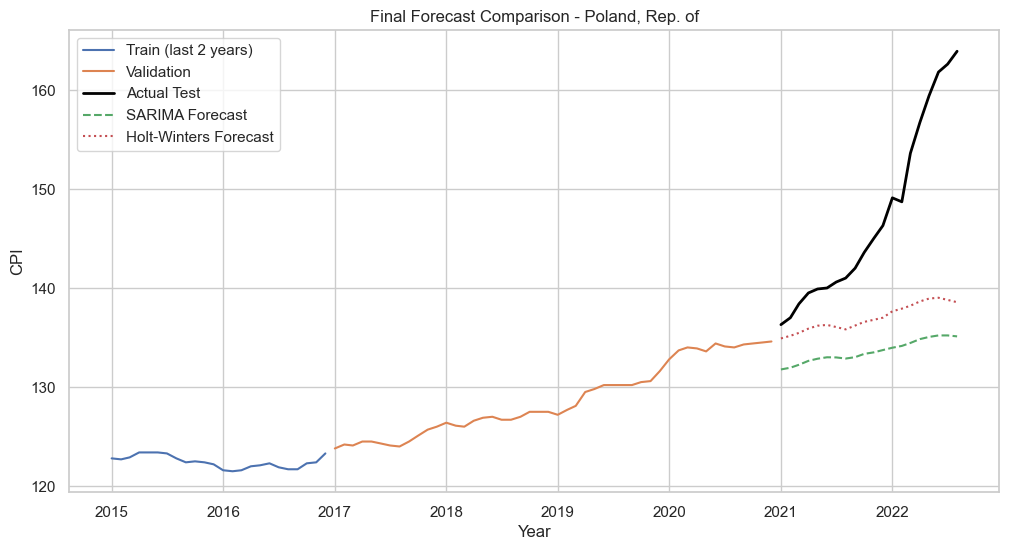

In [12]:
# Forecast on Test Set
sarima_test_pred = best_sarima_model.predict(start=test.index[0], end=test.index[-1])

best_hw_model = ExponentialSmoothing(train, trend=best_hw_trend, seasonal=best_hw_seasonal, seasonal_periods=12).fit()
hw_test_pred = best_hw_model.predict(start=test.index[0], end=test.index[-1])

def calculate_metrics(y_true, y_pred, name):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mape = mean_absolute_percentage_error(y_true, y_pred) * 100
    print(f"--- {name} Metrics ---")
    print(f"MAE: {mae:.4f}")
    print(f"RMSE: {rmse:.4f}")
    print(f"MAPE: {mape:.4f}%")
    return mae, rmse, mape

calculate_metrics(test, sarima_test_pred, "SARIMA")
calculate_metrics(test, hw_test_pred, "Holt-Winters")

# Final Forecast Plot
plt.figure(figsize=(12, 6))
plt.plot(train.iloc[-24:], label="Train (last 2 years)")
plt.plot(val, label="Validation")
plt.plot(test, label="Actual Test", color='black', linewidth=2)
plt.plot(sarima_test_pred, label="SARIMA Forecast", linestyle='--')
plt.plot(hw_test_pred, label="Holt-Winters Forecast", linestyle=':')
plt.title(f"Final Forecast Comparison - {primary_country}")
plt.xlabel("Year")
plt.ylabel("CPI")
plt.legend()
plt.show()